## Expert Knowledge Worker

### A question answering agent that is an expert knowledge worker
### To be used by employees of Insurellm, an Insurance Tech company
### The agent needs to be accurate and the solution should be low cost.

This project will use RAG (Retrieval Augmented Generation) to ensure our question/answering assistant has high accuracy.

In [1]:
# imports

import os
import glob
from dotenv import load_dotenv
import gradio as gr

In [2]:
# imports for langchain and Chroma and plotly

from langchain.document_loaders import DirectoryLoader, TextLoader
from langchain.text_splitter import CharacterTextSplitter
from langchain.schema import Document
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_chroma import Chroma
import numpy as np
from sklearn.manifold import TSNE
import plotly.graph_objects as go

In [3]:
# price is a factor for our company, so we're going to use a low cost model

MODEL = "gpt-4o-mini"
db_name = "vector_db"

In [4]:
# Load environment variables in a file called .env

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')

In [5]:
# Read in documents using LangChain's loaders
# Take everything in all the sub-folders of our knowledgebase

folders = glob.glob("knowledge-base/*")

# With thanks to CG and Jon R, students on the course, for this fix needed for some users 
text_loader_kwargs = {'encoding': 'utf-8'}
# If that doesn't work, some Windows users might need to uncomment the next line instead
# text_loader_kwargs={'autodetect_encoding': True}

documents = []
for folder in folders:
    doc_type = os.path.basename(folder)
    loader = DirectoryLoader(folder, glob="**/*.md", loader_cls=TextLoader, loader_kwargs=text_loader_kwargs)
    folder_docs = loader.load()
    for doc in folder_docs:
        doc.metadata["doc_type"] = doc_type
        documents.append(doc)

# Please note:

In the next cell, we split the text into chunks.

2 students let me know that the next cell crashed their computer.  
They were able to fix it by changing the chunk_size from 1,000 to 2,000 and the chunk_overlap from 200 to 400.  
This shouldn't be required; but if it happens to you, please make that change!  
(Note that LangChain may give a warning about a chunk being larger than 1,000 - this can be safely ignored).

_With much thanks to Steven W and Nir P for this valuable contribution._

In [6]:
text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = text_splitter.split_documents(documents)

Created a chunk of size 1088, which is longer than the specified 1000


In [7]:
len(chunks)

123

In [8]:
doc_types = set(chunk.metadata['doc_type'] for chunk in chunks)
print(f"Document types found: {', '.join(doc_types)}")

Document types found: company, employees, contracts, products


## A sidenote on Embeddings, and "Auto-Encoding LLMs"

We will be mapping each chunk of text into a Vector that represents the meaning of the text, known as an embedding.

OpenAI offers a model to do this, which we will use by calling their API with some LangChain code.

This model is an example of an "Auto-Encoding LLM" which generates an output given a complete input.
It's different to all the other LLMs we've discussed today, which are known as "Auto-Regressive LLMs", and generate future tokens based only on past context.

Another example of an Auto-Encoding LLMs is BERT from Google. In addition to embedding, Auto-encoding LLMs are often used for classification.

### Sidenote

In week 8 we will return to RAG and vector embeddings, and we will use an open-source vector encoder so that the data never leaves our computer - that's an important consideration when building enterprise systems and the data needs to remain internal.

In [9]:
# Put the chunks of data into a Vector Store that associates a Vector Embedding with each chunk

embeddings = OpenAIEmbeddings()

# If you would rather use the free Vector Embeddings from HuggingFace sentence-transformers
# Then replace embeddings = OpenAIEmbeddings()
# with:
# from langchain.embeddings import HuggingFaceEmbeddings
# embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

In [10]:
# Check if a Chroma Datastore already exists - if so, delete the collection to start from scratch

if os.path.exists(db_name):
    Chroma(persist_directory=db_name, embedding_function=embeddings).delete_collection()

In [11]:
# Create our Chroma vectorstore!

vectorstore = Chroma.from_documents(documents=chunks, embedding=embeddings, persist_directory=db_name)
print(f"Vectorstore created with {vectorstore._collection.count()} documents")

Vectorstore created with 123 documents


In [12]:
# Get one vector and find how many dimensions it has

collection = vectorstore._collection
sample_embedding = collection.get(limit=1, include=["embeddings"])["embeddings"][0]
dimensions = len(sample_embedding)
print(f"The vectors have {dimensions:,} dimensions")

The vectors have 1,536 dimensions


It's a 1536 dimension vector in the embedding space.

### What does `limit=1` mean in this code in `collection.get()`?

Good question — here’s what’s happening:

In this line:

```python
sample_embedding = collection.get(limit=1, include=["embeddings"])["embeddings"][0]
```

the parameter `limit=1` means:

> **Retrieve only one record (or document) from the collection.**

---

### Explanation step-by-step:

* `collection.get()` is a method provided by **ChromaDB** (the vector database used by LangChain under the hood).
* It fetches items (vector embeddings and metadata) from the collection.
* The arguments:

  * `limit=1`: return **only the first** record in the collection.
  * `include=["embeddings"]`: return **only the embeddings field** (not metadata, documents, or IDs).

So `collection.get(limit=1, include=["embeddings"])` returns something like:

```python
{
  "ids": ["some-id"],
  "embeddings": [[0.123, 0.456, ..., 0.789]],
}
```

Then the code takes the first (and only) embedding:

```python
sample_embedding = ...["embeddings"][0]
```

and finds its dimensionality:

```python
dimensions = len(sample_embedding)
```

---

✅ **In short:**
`limit=1` just means “give me one sample item from the collection” — enough to check the embedding vector’s dimension without loading all documents.

---

See more examples below:

In [18]:
# Get one vector and find how many dimensions it has

collection = vectorstore._collection
sample_embedding = collection.get(limit=2, include=["embeddings"])["embeddings"]
sample_embedding

array([[-0.01149175, -0.01443085, -0.00741044, ..., -0.00141035,
        -0.02829059, -0.01828929],
       [-0.01380237, -0.00485425, -0.00018299, ..., -0.00108627,
        -0.01701364, -0.0184801 ]], shape=(2, 1536))

In [19]:
for s in sample_embedding:
    print(s)

[-0.01149175 -0.01443085 -0.00741044 ... -0.00141035 -0.02829059
 -0.01828929]
[-0.01380237 -0.00485425 -0.00018299 ... -0.00108627 -0.01701364
 -0.0184801 ]


## Visualizing the Vector Store

Let's take a minute to look at the documents and their embedding vectors to see what's going on.

In [20]:
# Prework

result = collection.get(include=['embeddings', 'documents', 'metadatas'])
vectors = np.array(result['embeddings'])
documents = result['documents']
doc_types = [metadata['doc_type'] for metadata in result['metadatas']]
colors = [['blue', 'green', 'red', 'orange'][['products', 'employees', 'contracts', 'company'].index(t)] for t in doc_types]

Let’s break that line down — it looks a bit dense but it’s actually just **mapping document types to colors**.

Here’s the code:

```python
colors = [['blue', 'green', 'red', 'orange'][['products', 'employees', 'contracts', 'company'].index(t)] for t in doc_types]
```

---

### Step-by-step explanation

1. **There are two aligned lists:**

   ```python
   ['products', 'employees', 'contracts', 'company']
   ['blue', 'green', 'red', 'orange']
   ```

   Each document type corresponds to a color at the same index:

   * `'products'` → `'blue'`
   * `'employees'` → `'green'`
   * `'contracts'` → `'red'`
   * `'company'` → `'orange'`

2. **`doc_types`** is a list of document types (e.g., `['employees', 'company', 'products']`).

3. For each `t` in `doc_types`, this part:

   ```python
   ['products', 'employees', 'contracts', 'company'].index(t)
   ```

   finds the **index** of `t` in the list of known document types.

4. Then this part:

   ```python
   ['blue', 'green', 'red', 'orange'][that_index]
   ```

   picks the color corresponding to that index.

5. Finally, the list comprehension builds the full list of colors.

---

### Example

If:

```python
doc_types = ['employees', 'company', 'products']
```

Then:

* `'employees'` → `'green'`
* `'company'` → `'orange'`
* `'products'` → `'blue'`

✅ So the result is:

```python
colors = ['green', 'orange', 'blue']
```

---

### Summary

That line **maps each document type in `doc_types` to a pre-defined color** according to the order of the two reference lists.


In [21]:
colors

['blue',
 'blue',
 'blue',
 'blue',
 'blue',
 'blue',
 'blue',
 'blue',
 'blue',
 'blue',
 'blue',
 'blue',
 'blue',
 'blue',
 'blue',
 'blue',
 'blue',
 'blue',
 'blue',
 'blue',
 'blue',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'orange',
 'orange',
 'orange',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 '

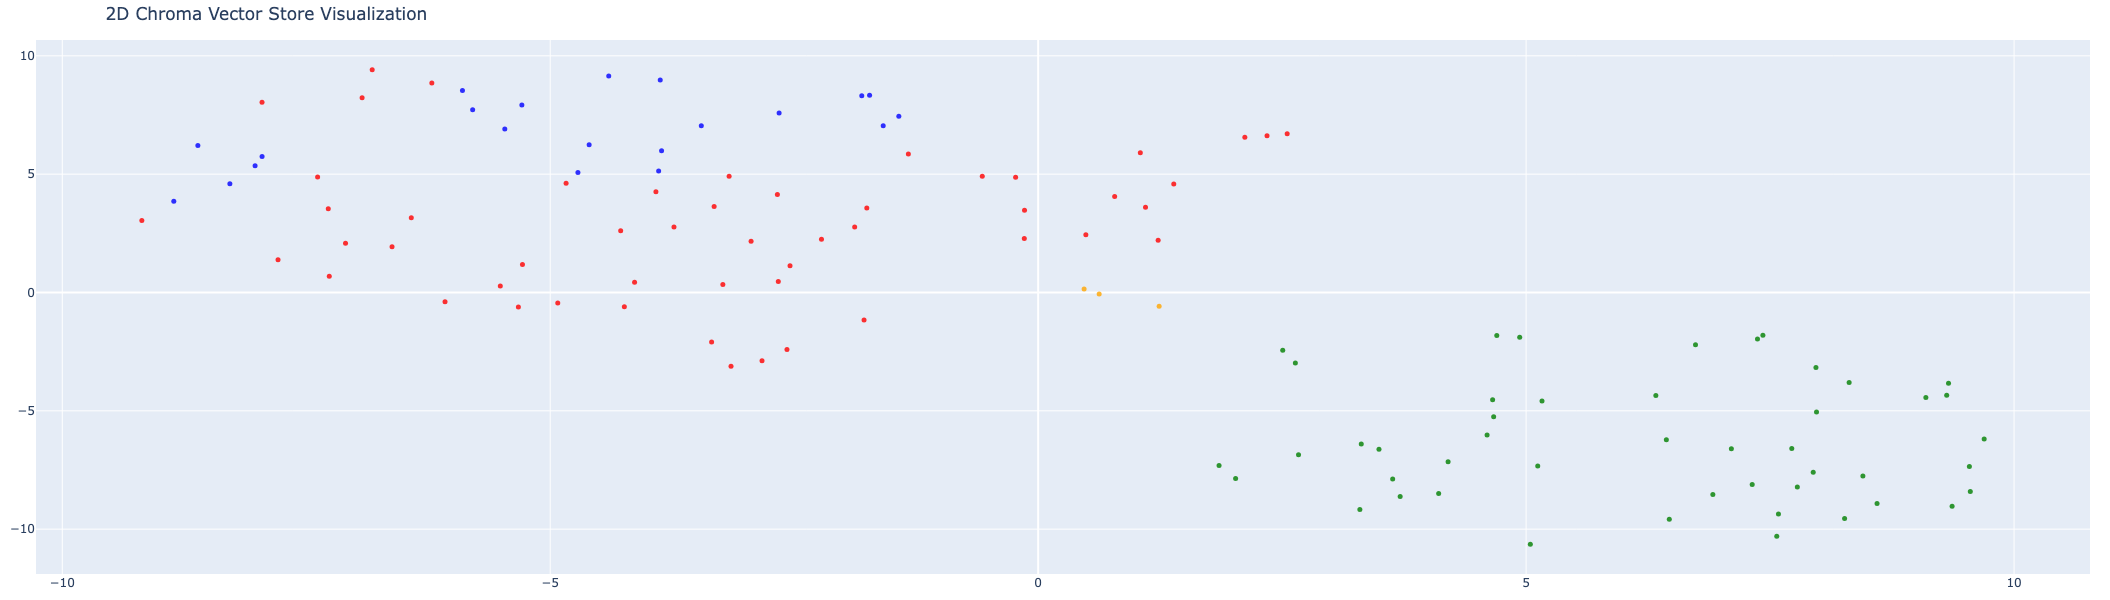

In [23]:
# We humans find it easier to visalize things in 2D!
# Reduce the dimensionality of the vectors to 2D using t-SNE
# (t-distributed stochastic neighbor embedding)

tsne = TSNE(n_components=2, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

# Create the 2D scatter plot
fig = go.Figure(data=[go.Scatter(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t, d in zip(doc_types, documents)],
    hoverinfo='text'
)])

fig.update_layout(
    title='2D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x',yaxis_title='y'),
    width=800,
    height=600,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()

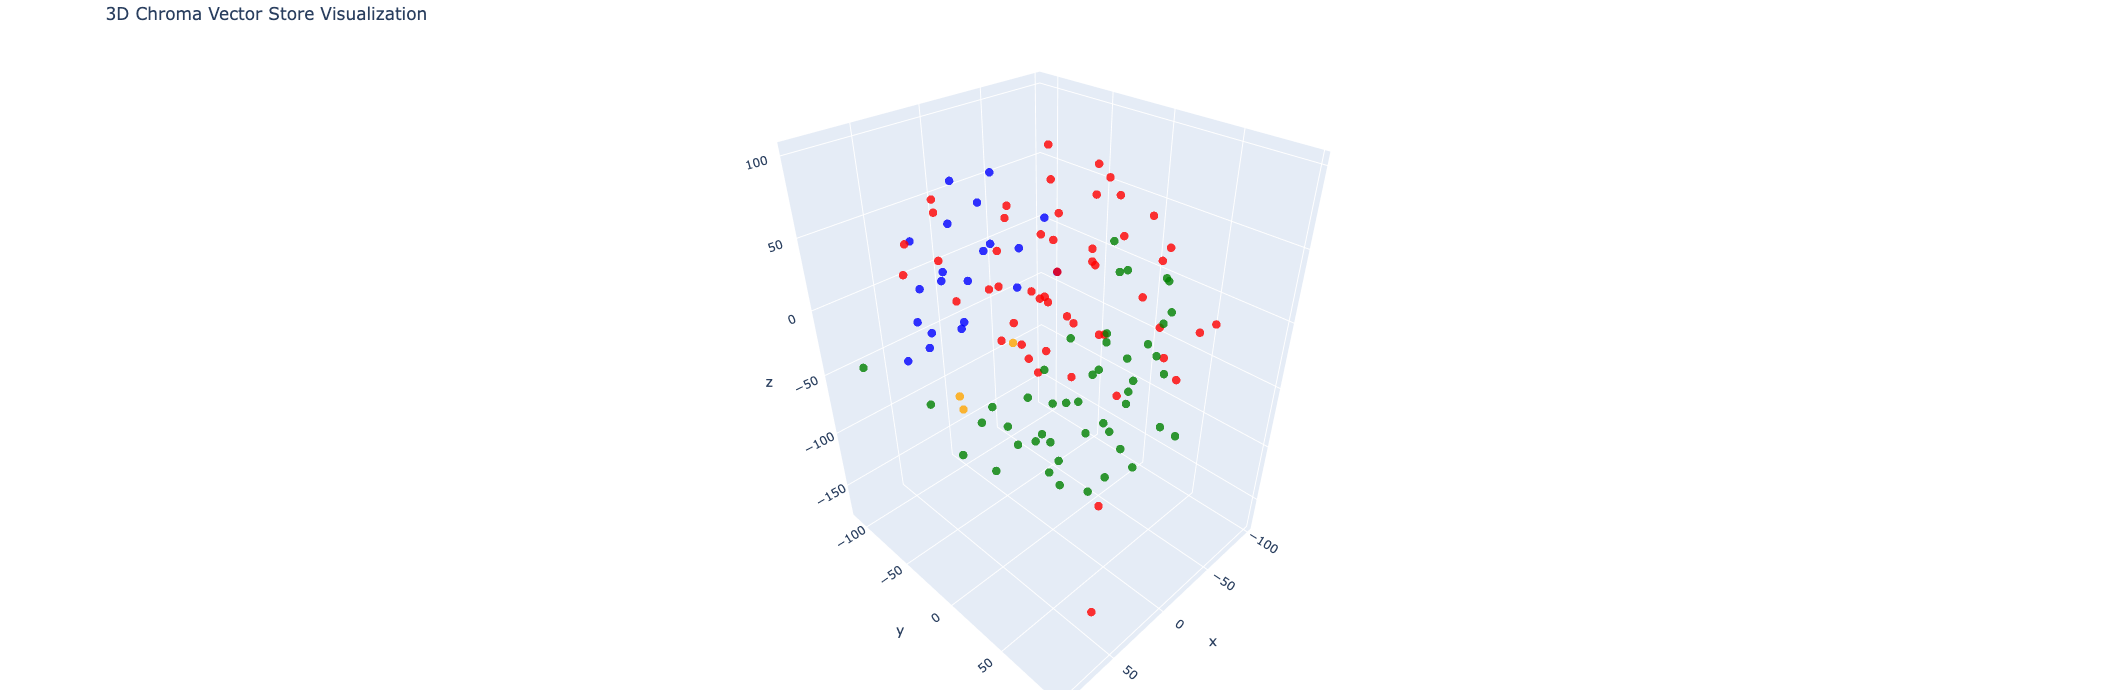

In [24]:
# Let's try 3D!

tsne = TSNE(n_components=3, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

# Create the 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    z=reduced_vectors[:, 2],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t, d in zip(doc_types, documents)],
    hoverinfo='text'
)])

fig.update_layout(
    title='3D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z'),
    width=900,
    height=700,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()

# UMAP:

## Overview:

**UMAP** stands for **Uniform Manifold Approximation and Projection**. It’s a **dimensionality reduction technique** commonly used to visualize high-dimensional data (like embeddings) in 2D or 3D. It’s often compared to t-SNE but is faster and can preserve more global structure.

---

### 🧠 Intuition

UMAP tries to **map high-dimensional data to a lower-dimensional space** while preserving both:

1. **Local structure** – points that are close together remain close.
2. **Global structure** – overall shape or clusters of the data are preserved better than t-SNE.

It does this by:

* Constructing a **graph of relationships** in high-dimensional space.
* Optimizing a lower-dimensional embedding that best maintains those relationships.

---

### ⚙️ Key Features

* **Fast and scalable** – works well with tens or hundreds of thousands of points.
* **Preserves both local and global structure** better than t-SNE.
* **Deterministic** (with a fixed random seed) and can embed new points into an existing projection.
* Often produces **cleaner cluster separation** for visualization.

---

### 📊 Example in Python

```python
import umap
import matplotlib.pyplot as plt

# X = high-dimensional data (e.g., 768-dim embeddings)
reducer = umap.UMAP(n_components=2, random_state=42)
X_2d = reducer.fit_transform(X)

plt.scatter(X_2d[:,0], X_2d[:,1])
plt.title("UMAP projection of embeddings")
plt.show()
```

---

### ✅ When to use UMAP

* Visualizing high-dimensional data like **word embeddings, image features, or tabular datasets**.
* Exploring **clusters or patterns** in your data.
* When you want **faster computation** or to **embed new points** into an existing projection.

---

If you want, I can make a **side-by-side comparison of t-SNE vs UMAP with pros, cons, and typical use cases** for easy reference. Do you want me to do that?


## More Details

Let’s go **step by step** and break down how UMAP does this in more detail. I’ll keep it intuitive but also technically accurate.

---

### **Step 1: Construct a graph of relationships in high-dimensional space**

1. **Start with your high-dimensional points**
   For example, you might have 768-dimensional embeddings for text or images. Each point represents one data sample.

2. **Define “neighbors” for each point**

   * UMAP looks at each point and identifies its **k nearest neighbors** (where `k` is a hyperparameter called `n_neighbors`).
   * This captures the **local structure** of the data: points close to each other in high-dimensional space are likely related.

3. **Compute a weighted graph**

   * Each point is a **node** in a graph.
   * Edges connect a point to its neighbors.
   * The **weight of an edge** represents the **strength of similarity** between the points (closer points → higher weight).
   * This graph captures the **fuzzy topology** of your data: it represents which points are “nearby” in high dimensions.

> Think of it as a network showing how each point is connected to its closest friends.

---

### **Step 2: Optimize a low-dimensional embedding**

1. **Initialize low-dimensional coordinates**

   * Start by placing points randomly in 2D or 3D space.

2. **Preserve relationships**

   * UMAP tries to **match the high-dimensional graph** in the low-dimensional space.
   * Points connected by strong edges (i.e., close neighbors in high-dimensional space) should be **close together in 2D/3D**.
   * Points with weak or no connection should be **far apart**.

3. **Use a mathematical objective (loss function)**

   * The algorithm minimizes a **cross-entropy–style loss**: it penalizes points that are close in high-dimensional space but far apart in low-dimensional space, or vice versa.
   * This process iteratively adjusts the 2D/3D positions until the low-dimensional embedding best represents the original relationships.

---

### **Intuition**

* Imagine your high-dimensional data is a **crumpled piece of paper**.
* UMAP is like **carefully flattening it** onto a table so that points that were near each other in the crumpled paper stay near each other on the table, and points far apart stay far apart as much as possible.
* The difference from t-SNE: UMAP also tries to **preserve more of the overall shape** (global structure), not just local clusters.

---

### ✅ **Key Hyperparameters**

* `n_neighbors`: controls **local vs global structure**. Small → more local, Large → more global.
* `min_dist`: controls **how tightly points cluster** in low-dimensional space. Smaller → tighter clusters.

---

If you want, I can **draw a simple visual diagram** showing UMAP’s high-dimensional graph and how it gets flattened into 2D. It makes the process super clear. Do you want me to do that?


# Let’s compare **t-SNE vs. UMAP**, since both are popular for visualizing high-dimensional data like embeddings:

---

### **1. t-SNE (t-Distributed Stochastic Neighbor Embedding)**

**Pros:**

* Excellent at preserving **local structure** — nearby points in high-dimensional space stay close in 2D/3D.
* Widely used and well-known in ML and NLP communities.

**Cons:**

* **Slow** on large datasets (especially >10,000 points).
* Does **not preserve global structure well** — clusters may appear farther apart or closer than they really are.
* **Non-parametric**: once projected, you can’t easily embed new points without rerunning t-SNE.
* **Stochastic**: each run can give slightly different visualizations.

---

### **2. UMAP (Uniform Manifold Approximation and Projection)**

**Pros:**

* Faster and more scalable than t-SNE — works well on large datasets.
* Preserves both **local and global structure** better than t-SNE.
* Can be used **as a transformer** to embed new points without recomputing the whole projection.
* Often produces **more meaningful cluster separation** for large, complex datasets.

**Cons:**

* Slightly more sensitive to **hyperparameters** (`n_neighbors`, `min_dist`) which can affect how tight or spread clusters appear.
* May be a bit less “familiar” to some audiences than t-SNE.

---

### **Summary Table**

| Feature              | t-SNE                                               | UMAP                                                             |
| -------------------- | --------------------------------------------------- | ---------------------------------------------------------------- |
| Speed / Scalability  | Slow                                                | Fast / scalable                                                  |
| Local structure      | Excellent                                           | Excellent                                                        |
| Global structure     | Poor                                                | Better than t-SNE                                                |
| Deterministic        | No (stochastic)                                     | Can be deterministic                                             |
| Transform new points | No                                                  | Yes                                                              |
| Typical use case     | Small-to-medium datasets, exploratory visualization | Large datasets, embedding visualization, downstream use possible |

---

✅ **Rule of thumb:**

* Use **t-SNE** if your dataset is small and you care mostly about local clusters.
* Use **UMAP** if you have a larger dataset, want faster computation, and want to preserve more of the global relationships.

---